# Notebook 01 - Data Preparation and EDA

## Project Overview

In this notebook, we build the cleaned base dataset for the flight delay prediction project. The data comes from monthly flight files from 2023, 2024, and 2025. In total, the project expects 36 monthly CSV files. This extended dataset is used to increase the amount of training data and improve the representation of less frequent delay classes.

The target is a 3-class delay severity variable:

- 0 - On time: arrival delay of 15 minutes or less.
- 1 - Delay: arrival delay from 16 to 90 minutes.
- 2 - Long delay: arrival delay greater than 90 minutes.

We use this 3-class target because the original 5-class idea created stronger imbalance and was less stable for modeling.


In [6]:
from pathlib import Path
import polars as pl
import matplotlib.pyplot as plt

## Project Paths

This section defines the project folders used in the notebook. The generated folder stores intermediate datasets and summaries that are reused by the next notebooks.


In [7]:
BASE_DIR = Path.cwd().parent

RAW_DIR = BASE_DIR / "data" / "raw" / "flights"
GENERATED_DIR = BASE_DIR / "data" / "generated"

GENERATED_DIR.mkdir(parents=True, exist_ok=True)

## Loading Monthly Flight Files

We first check the raw data folder and list the monthly CSV files. The expected input is the 36 monthly files for 2023-2025.

In [8]:
print("BASE_DIR:", BASE_DIR)
print("RAW_DIR:", RAW_DIR)
print("RAW_DIR exists:", RAW_DIR.exists())

csv_files = sorted(RAW_DIR.glob("*.csv"))

print(f"Total files found: {len(csv_files)}")

for file in csv_files:
    print(file.name)

BASE_DIR: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos
RAW_DIR: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\data\raw\flights
RAW_DIR exists: True
Total files found: 36
T_ONTIME_REPORTING(1).csv
T_ONTIME_REPORTING(10).csv
T_ONTIME_REPORTING(11).csv
T_ONTIME_REPORTING(12).csv
T_ONTIME_REPORTING(13).csv
T_ONTIME_REPORTING(14).csv
T_ONTIME_REPORTING(15).csv
T_ONTIME_REPORTING(16).csv
T_ONTIME_REPORTING(17).csv
T_ONTIME_REPORTING(18).csv
T_ONTIME_REPORTING(19).csv
T_ONTIME_REPORTING(2).csv
T_ONTIME_REPORTING(20).csv
T_ONTIME_REPORTING(21).csv
T_ONTIME_REPORTING(22).csv
T_ONTIME_REPORTING(23).csv
T_ONTIME_REPORTING(24).csv
T_ONTIME_REPORTING(25).csv
T_ONTIME_REPORTING(26).csv
T_ONTIME_REPORTING(27).csv
T_ONTIME_REPORTING(28).csv
T_ONTIME_REPORTING(29).csv
T_ONTIME_REPORTING(3).csv
T_ONTIME_REPORTING(30).csv
T_ONTIME_REPORTING(31).csv
T_ONTIME_REPORTING(32).csv
T_ONTIME_REPORTING(33).csv
T_ONTIME_REPORTING(34).csv
T_ONTIME_R

The next cell reads each monthly CSV file, adds the source file name, and combines all months into one Polars DataFrame. This keeps the raw monthly origin of each row available for validation.


In [9]:
dfs = []

for file in csv_files:
    print(f"Reading: {file.name}")
    
    df_month = pl.read_csv(
        file,
        infer_schema_length=10000,
        ignore_errors=True
    )
    
    df_month = df_month.with_columns(
        pl.lit(file.name).alias("source_file")
    )
    
    dfs.append(df_month)

df = pl.concat(dfs, how="vertical_relaxed")

print(df.shape)

Reading: T_ONTIME_REPORTING(1).csv
Reading: T_ONTIME_REPORTING(10).csv
Reading: T_ONTIME_REPORTING(11).csv
Reading: T_ONTIME_REPORTING(12).csv
Reading: T_ONTIME_REPORTING(13).csv
Reading: T_ONTIME_REPORTING(14).csv
Reading: T_ONTIME_REPORTING(15).csv
Reading: T_ONTIME_REPORTING(16).csv
Reading: T_ONTIME_REPORTING(17).csv
Reading: T_ONTIME_REPORTING(18).csv
Reading: T_ONTIME_REPORTING(19).csv
Reading: T_ONTIME_REPORTING(2).csv
Reading: T_ONTIME_REPORTING(20).csv
Reading: T_ONTIME_REPORTING(21).csv
Reading: T_ONTIME_REPORTING(22).csv
Reading: T_ONTIME_REPORTING(23).csv
Reading: T_ONTIME_REPORTING(24).csv
Reading: T_ONTIME_REPORTING(25).csv
Reading: T_ONTIME_REPORTING(26).csv
Reading: T_ONTIME_REPORTING(27).csv
Reading: T_ONTIME_REPORTING(28).csv
Reading: T_ONTIME_REPORTING(29).csv
Reading: T_ONTIME_REPORTING(3).csv
Reading: T_ONTIME_REPORTING(30).csv
Reading: T_ONTIME_REPORTING(31).csv
Reading: T_ONTIME_REPORTING(32).csv
Reading: T_ONTIME_REPORTING(33).csv
Reading: T_ONTIME_REPORTING(34)

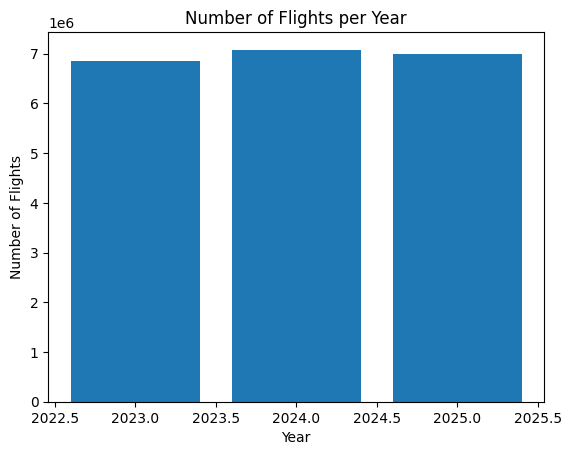

In [10]:
year_counts = (
    df.group_by("YEAR")
      .agg(pl.len().alias("num_flights"))
      .sort("YEAR")
)

plt.bar(year_counts["YEAR"], year_counts["num_flights"])
plt.title("Number of Flights per Year")
plt.xlabel("Year")
plt.ylabel("Number of Flights")
plt.show()

## Dataset Validation

Before cleaning, we inspect the columns, schema, sample rows, and dataset size. This helps confirm that the monthly files were merged correctly.


In [11]:
df.columns

['YEAR',
 'MONTH',
 'DAY_OF_WEEK',
 'FL_DATE',
 'OP_UNIQUE_CARRIER',
 'ORIGIN_AIRPORT_SEQ_ID',
 'ORIGIN',
 'ORIGIN_CITY_NAME',
 'ORIGIN_STATE_ABR',
 'DEST',
 'DEST_CITY_NAME',
 'DEST_STATE_ABR',
 'CRS_DEP_TIME',
 'DEP_TIME',
 'DEP_DELAY',
 'DEP_DELAY_NEW',
 'DEP_DEL15',
 'DEP_TIME_BLK',
 'TAXI_OUT',
 'TAXI_IN',
 'ARR_TIME',
 'ARR_DELAY',
 'ARR_DELAY_NEW',
 'ARR_DEL15',
 'ARR_TIME_BLK',
 'CANCELLED',
 'CANCELLATION_CODE',
 'AIR_TIME',
 'DISTANCE',
 'CARRIER_DELAY',
 'WEATHER_DELAY',
 'NAS_DELAY',
 'SECURITY_DELAY',
 'LATE_AIRCRAFT_DELAY',
 'source_file']

In [12]:
df.schema

Schema([('YEAR', Int64),
        ('MONTH', Int64),
        ('DAY_OF_WEEK', Int64),
        ('FL_DATE', String),
        ('OP_UNIQUE_CARRIER', String),
        ('ORIGIN_AIRPORT_SEQ_ID', Int64),
        ('ORIGIN', String),
        ('ORIGIN_CITY_NAME', String),
        ('ORIGIN_STATE_ABR', String),
        ('DEST', String),
        ('DEST_CITY_NAME', String),
        ('DEST_STATE_ABR', String),
        ('CRS_DEP_TIME', Int64),
        ('DEP_TIME', Int64),
        ('DEP_DELAY', Float64),
        ('DEP_DELAY_NEW', Float64),
        ('DEP_DEL15', Float64),
        ('DEP_TIME_BLK', String),
        ('TAXI_OUT', Float64),
        ('TAXI_IN', Float64),
        ('ARR_TIME', Int64),
        ('ARR_DELAY', Float64),
        ('ARR_DELAY_NEW', Float64),
        ('ARR_DEL15', Float64),
        ('ARR_TIME_BLK', String),
        ('CANCELLED', Float64),
        ('CANCELLATION_CODE', String),
        ('AIR_TIME', Float64),
        ('DISTANCE', Float64),
        ('CARRIER_DELAY', Float64),
        ('WEATHE

In [13]:
df.head()

YEAR,MONTH,DAY_OF_WEEK,FL_DATE,OP_UNIQUE_CARRIER,ORIGIN_AIRPORT_SEQ_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,DEST,DEST_CITY_NAME,DEST_STATE_ABR,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DELAY_NEW,DEP_DEL15,DEP_TIME_BLK,TAXI_OUT,TAXI_IN,ARR_TIME,ARR_DELAY,ARR_DELAY_NEW,ARR_DEL15,ARR_TIME_BLK,CANCELLED,CANCELLATION_CODE,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,source_file
i64,i64,i64,str,str,i64,str,str,str,str,str,str,i64,i64,f64,f64,f64,str,f64,f64,i64,f64,f64,f64,str,f64,str,f64,f64,f64,f64,f64,f64,f64,str
2023,7,1,"""7/3/2023 12:00:00 AM""","""9E""",1013506,"""ABE""","""Allentown/Bethlehem/Easton, PA""","""PA""","""ATL""","""Atlanta, GA""","""GA""",654,655,1.0,1.0,0.0,"""0600-0659""",11.0,9.0,855,-9.0,0.0,0.0,"""0900-0959""",0.0,null,100.0,692.0,null,null,null,null,null,"""T_ONTIME_REPORTING(1).csv"""
2023,7,1,"""7/3/2023 12:00:00 AM""","""9E""",1013506,"""ABE""","""Allentown/Bethlehem/Easton, PA""","""PA""","""ATL""","""Atlanta, GA""","""GA""",1420,1422,2.0,2.0,0.0,"""1400-1459""",13.0,5.0,1624,-9.0,0.0,0.0,"""1600-1659""",0.0,null,104.0,692.0,null,null,null,null,null,"""T_ONTIME_REPORTING(1).csv"""
2023,7,1,"""7/3/2023 12:00:00 AM""","""9E""",1014602,"""ABY""","""Albany, GA""","""GA""","""ATL""","""Atlanta, GA""","""GA""",730,725,-5.0,0.0,0.0,"""0700-0759""",17.0,10.0,831,-14.0,0.0,0.0,"""0800-0859""",0.0,null,39.0,145.0,null,null,null,null,null,"""T_ONTIME_REPORTING(1).csv"""
2023,7,1,"""7/3/2023 12:00:00 AM""","""9E""",1014602,"""ABY""","""Albany, GA""","""GA""","""ATL""","""Atlanta, GA""","""GA""",1400,1352,-8.0,0.0,0.0,"""1400-1459""",10.0,9.0,1448,-19.0,0.0,0.0,"""1500-1559""",0.0,null,37.0,145.0,null,null,null,null,null,"""T_ONTIME_REPORTING(1).csv"""
2023,7,1,"""7/3/2023 12:00:00 AM""","""9E""",1018502,"""AEX""","""Alexandria, LA""","""LA""","""ATL""","""Atlanta, GA""","""GA""",612,608,-4.0,0.0,0.0,"""0600-0659""",21.0,12.0,855,-9.0,0.0,0.0,"""0900-0959""",0.0,null,74.0,500.0,null,null,null,null,null,"""T_ONTIME_REPORTING(1).csv"""


In [14]:
print("Dataset shape:", df.shape)
print("Total rows:", df.height)
print("Total columns:", len(df.columns))

Dataset shape: (20928599, 35)
Total rows: 20928599
Total columns: 35


In [15]:
df.columns

['YEAR',
 'MONTH',
 'DAY_OF_WEEK',
 'FL_DATE',
 'OP_UNIQUE_CARRIER',
 'ORIGIN_AIRPORT_SEQ_ID',
 'ORIGIN',
 'ORIGIN_CITY_NAME',
 'ORIGIN_STATE_ABR',
 'DEST',
 'DEST_CITY_NAME',
 'DEST_STATE_ABR',
 'CRS_DEP_TIME',
 'DEP_TIME',
 'DEP_DELAY',
 'DEP_DELAY_NEW',
 'DEP_DEL15',
 'DEP_TIME_BLK',
 'TAXI_OUT',
 'TAXI_IN',
 'ARR_TIME',
 'ARR_DELAY',
 'ARR_DELAY_NEW',
 'ARR_DEL15',
 'ARR_TIME_BLK',
 'CANCELLED',
 'CANCELLATION_CODE',
 'AIR_TIME',
 'DISTANCE',
 'CARRIER_DELAY',
 'WEATHER_DELAY',
 'NAS_DELAY',
 'SECURITY_DELAY',
 'LATE_AIRCRAFT_DELAY',
 'source_file']

In [16]:
df.schema

Schema([('YEAR', Int64),
        ('MONTH', Int64),
        ('DAY_OF_WEEK', Int64),
        ('FL_DATE', String),
        ('OP_UNIQUE_CARRIER', String),
        ('ORIGIN_AIRPORT_SEQ_ID', Int64),
        ('ORIGIN', String),
        ('ORIGIN_CITY_NAME', String),
        ('ORIGIN_STATE_ABR', String),
        ('DEST', String),
        ('DEST_CITY_NAME', String),
        ('DEST_STATE_ABR', String),
        ('CRS_DEP_TIME', Int64),
        ('DEP_TIME', Int64),
        ('DEP_DELAY', Float64),
        ('DEP_DELAY_NEW', Float64),
        ('DEP_DEL15', Float64),
        ('DEP_TIME_BLK', String),
        ('TAXI_OUT', Float64),
        ('TAXI_IN', Float64),
        ('ARR_TIME', Int64),
        ('ARR_DELAY', Float64),
        ('ARR_DELAY_NEW', Float64),
        ('ARR_DEL15', Float64),
        ('ARR_TIME_BLK', String),
        ('CANCELLED', Float64),
        ('CANCELLATION_CODE', String),
        ('AIR_TIME', Float64),
        ('DISTANCE', Float64),
        ('CARRIER_DELAY', Float64),
        ('WEATHE

The unified raw dataset is saved as a parquet file. This gives us a reproducible raw checkpoint before any cleaning or target engineering.


In [17]:
raw_output_path = GENERATED_DIR / "flights_2023_2025_raw.parquet"

df.write_parquet(raw_output_path)

print(f"Raw unified dataset saved at: {raw_output_path}")

Raw unified dataset saved at: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\data\generated\flights_2023_2025_raw.parquet


We also validate the number of records per month and by source file. This check is useful because missing or duplicated months would affect the temporal modeling step later.


In [18]:
monthly_counts = (
    df.group_by("MONTH")
      .agg(pl.len().alias("num_flights"))
      .sort("MONTH")
)

monthly_counts

MONTH,num_flights
i64,u32
1,1625855
2,1526854
3,1772961
4,1727596
5,1795349
…,…
8,1824390
9,1714399
10,1820309


In [19]:
source_month_validation = (
    df.group_by(["source_file", "MONTH"])
      .agg(pl.len().alias("num_rows"))
      .sort(["source_file", "MONTH"])
)

source_month_validation

source_file,MONTH,num_rows
str,i64,u32
"""T_ONTIME_REPORTING(1).csv""",7,601866
"""T_ONTIME_REPORTING(10).csv""",10,615497
"""T_ONTIME_REPORTING(11).csv""",9,582622
"""T_ONTIME_REPORTING(12).csv""",8,619025
"""T_ONTIME_REPORTING(13).csv""",7,634613
…,…,…
"""T_ONTIME_REPORTING(6).csv""",2,502749
"""T_ONTIME_REPORTING(7).csv""",1,538837
"""T_ONTIME_REPORTING(8).csv""",12,590581


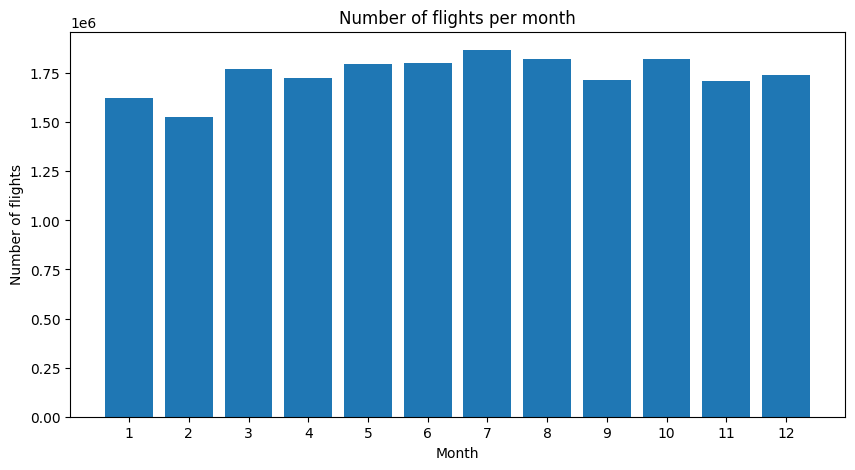

In [20]:
plt.figure(figsize=(10, 5))
plt.bar(
    monthly_counts["MONTH"].to_list(),
    monthly_counts["num_flights"].to_list()
)
plt.xlabel("Month")
plt.ylabel("Number of flights")
plt.title("Number of flights per month")
plt.xticks(monthly_counts["MONTH"].to_list())
plt.show()

## Cleaning Cancelled and Invalid Flights

This section prepares the arrival delay field for modeling. We parse the flight date, review missing values, and remove cancelled flights or rows where arrival delay is missing.


In [21]:
df = df.with_columns(
    pl.col("FL_DATE")
      .str.split(" ")
      .list.get(0)
      .str.strptime(pl.Date, format="%m/%d/%Y", strict=False)
      .alias("flight_date")
)

In [22]:
df.select(
    pl.col("flight_date").is_null().sum().alias("invalid_flight_dates")
)

invalid_flight_dates
u32
0


In [23]:
total_rows = df.height

null_summary = pl.DataFrame({
    "column": df.columns,
    "null_count": [
        df.select(pl.col(col).is_null().sum()).item()
        for col in df.columns
    ]
}).with_columns(
    ((pl.col("null_count") / total_rows) * 100).round(2).alias("null_percentage")
).sort("null_percentage", descending=True)

null_summary

column,null_count,null_percentage
str,i64,f64
"""CANCELLATION_CODE""",20641465,98.63
"""CARRIER_DELAY""",16557293,79.11
"""WEATHER_DELAY""",16557293,79.11
"""NAS_DELAY""",16557293,79.11
"""SECURITY_DELAY""",16557293,79.11
…,…,…
"""ARR_TIME_BLK""",0,0.0
"""CANCELLED""",0,0.0
"""DISTANCE""",0,0.0


In [24]:
cancelled_summary = (
    df.group_by("CANCELLED")
      .agg(pl.len().alias("count"))
      .with_columns(
          ((pl.col("count") / df.height) * 100).round(2).alias("percentage")
      )
      .sort("CANCELLED")
)

cancelled_summary

CANCELLED,count,percentage
f64,u32,f64
0.0,20641465,98.63
1.0,287134,1.37


Cancelled flights and rows without `ARR_DELAY` cannot be used for the delay severity target. Removing them keeps the target definition consistent.


In [25]:
df_clean = df.filter(
    (pl.col("CANCELLED") == 0) &
    (pl.col("ARR_DELAY").is_not_null())
)

print("Original rows:", df.height)
print("Clean rows:", df_clean.height)
print("Removed rows:", df.height - df_clean.height)

Original rows: 20928599
Clean rows: 20588154
Removed rows: 340445


Negative arrival delays mean the flight arrived early. For delay severity, early arrivals are treated as 0 delay minutes.


In [26]:
df_clean = df_clean.with_columns(
    pl.when(pl.col("ARR_DELAY") < 0)
      .then(0.0)
      .otherwise(pl.col("ARR_DELAY"))
      .alias("ARR_DELAY_MINUTES")
)   

In [27]:
df_clean.select([
    pl.col("ARR_DELAY").min().alias("original_min_arr_delay"),
    pl.col("ARR_DELAY").max().alias("original_max_arr_delay"),
    pl.col("ARR_DELAY_MINUTES").min().alias("clean_min_arr_delay"),
    pl.col("ARR_DELAY_MINUTES").max().alias("clean_max_arr_delay"),
    pl.col("ARR_DELAY_MINUTES").mean().round(2).alias("avg_delay_minutes"),
    pl.col("ARR_DELAY_MINUTES").median().alias("median_delay_minutes"),
])

original_min_arr_delay,original_max_arr_delay,clean_min_arr_delay,clean_max_arr_delay,avg_delay_minutes,median_delay_minutes
f64,f64,f64,f64,f64,f64
-128.0,4405.0,0.0,4405.0,16.14,0.0


## Target Variable Creation

Here we convert `ARR_DELAY_MINUTES` into the final 3-class target. The classes are designed to separate normal operations, regular delays, and long delays.


In [28]:
df_clean = df_clean.with_columns(
    pl.when(pl.col("ARR_DELAY_MINUTES") <= 15)
      .then(0)
      .when(pl.col("ARR_DELAY_MINUTES") <= 90)
      .then(1)
      .otherwise(2)
      .alias("delay_class")
)

In [29]:
df_clean = df_clean.with_columns(
    pl.when(pl.col("delay_class") == 0)
      .then(pl.lit("On time"))
      .when(pl.col("delay_class") == 1)
      .then(pl.lit("Delay"))
      .otherwise(pl.lit("Long delay"))
      .alias("delay_class_name")
)

In [30]:
df_clean.select([
    "ARR_DELAY",
    "ARR_DELAY_MINUTES",
    "delay_class",
    "delay_class_name"
]).head(10)

ARR_DELAY,ARR_DELAY_MINUTES,delay_class,delay_class_name
f64,f64,i32,str
-9.0,0.0,0,"""On time"""
-9.0,0.0,0,"""On time"""
-14.0,0.0,0,"""On time"""
-19.0,0.0,0,"""On time"""
-9.0,0.0,0,"""On time"""
-17.0,0.0,0,"""On time"""
-21.0,0.0,0,"""On time"""
-24.0,0.0,0,"""On time"""
0.0,0.0,0,"""On time"""


## Class Distribution Analysis

The next cells show how many records belong to each delay class. This is important because the dataset has many more on-time flights than long-delay flights.


In [31]:
class_distribution = (
    df_clean.group_by(["delay_class", "delay_class_name"])
      .agg(pl.len().alias("count"))
      .with_columns(
          ((pl.col("count") / df_clean.height) * 100).round(4).alias("percentage")
      )
      .sort("delay_class")
)

class_distribution

delay_class,delay_class_name,count,percentage
i32,str,u32,f64
0,"""On time""",16357376,79.4504
1,"""Delay""",3298671,16.0222
2,"""Long delay""",932107,4.5274


The distribution confirms the imbalance in the problem. Most flights are on time, while long delays are a much smaller group. This matters because a model can look accurate by mostly predicting the majority class.


In [32]:
class_distribution.write_csv(GENERATED_DIR / "delay_class_distribution.csv")

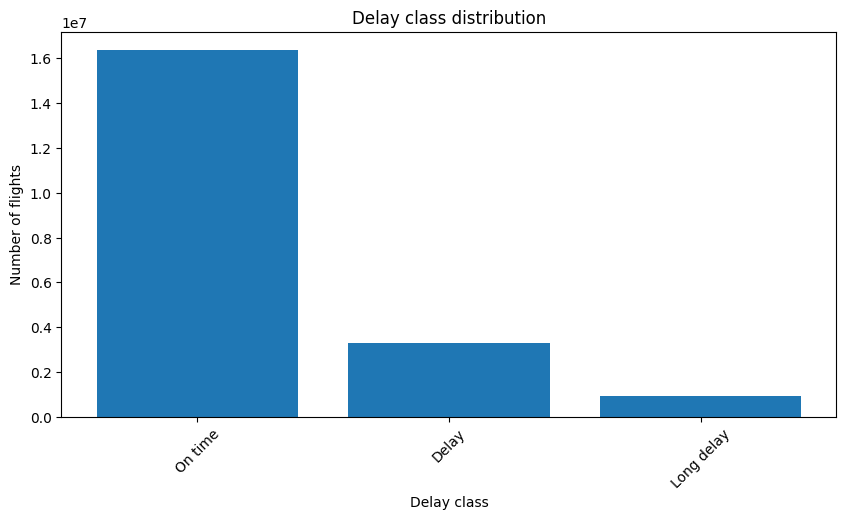

In [33]:
plt.figure(figsize=(10, 5))
plt.bar(
    class_distribution["delay_class_name"].to_list(),
    class_distribution["count"].to_list()
)
plt.xlabel("Delay class")
plt.ylabel("Number of flights")
plt.title("Delay class distribution")
plt.xticks(rotation=45)
plt.show()

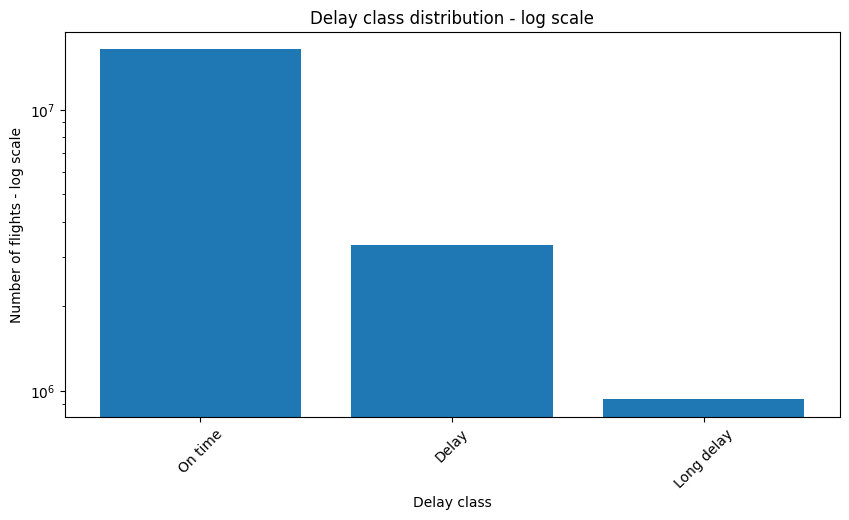

In [34]:
plt.figure(figsize=(10, 5))
plt.bar(
    class_distribution["delay_class_name"].to_list(),
    class_distribution["count"].to_list()
)
plt.xlabel("Delay class")
plt.ylabel("Number of flights - log scale")
plt.title("Delay class distribution - log scale")
plt.yscale("log")
plt.xticks(rotation=45)
plt.show()

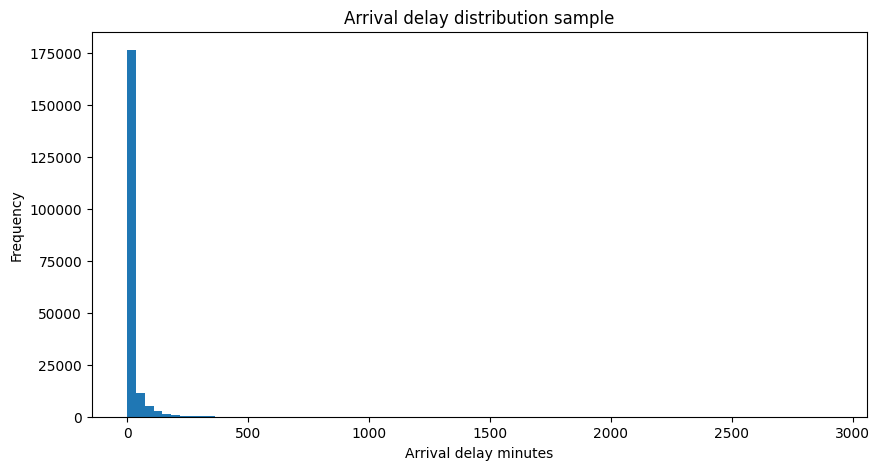

In [35]:
delay_sample = (
    df_clean.select("ARR_DELAY_MINUTES")
            .sample(n=200_000, seed=42)
)

plt.figure(figsize=(10, 5))
plt.hist(delay_sample["ARR_DELAY_MINUTES"].to_list(), bins=80)
plt.xlabel("Arrival delay minutes")
plt.ylabel("Frequency")
plt.title("Arrival delay distribution sample")
plt.show()

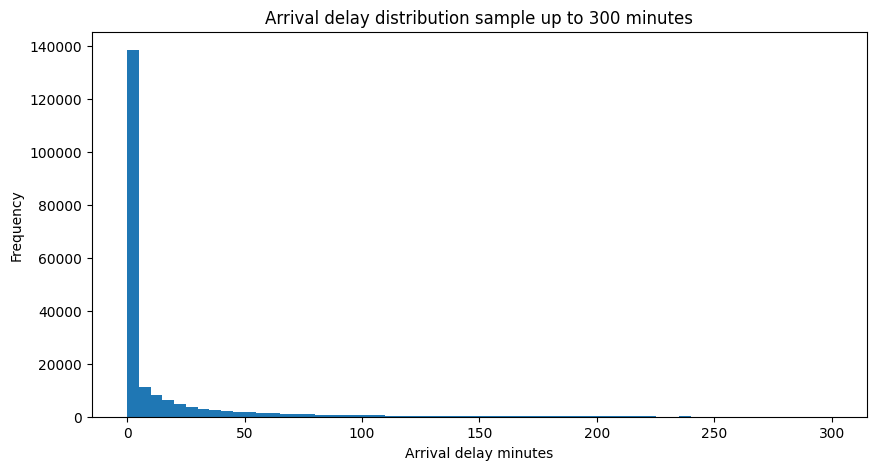

In [36]:
delay_sample_limited = delay_sample.filter(
    pl.col("ARR_DELAY_MINUTES") <= 300
)

plt.figure(figsize=(10, 5))
plt.hist(delay_sample_limited["ARR_DELAY_MINUTES"].to_list(), bins=60)
plt.xlabel("Arrival delay minutes")
plt.ylabel("Frequency")
plt.title("Arrival delay distribution sample up to 300 minutes")
plt.show()

## Feature Selection for Modeling

Now we create route and scheduled time features that are available before the flight takes place. These features can be used for prediction without using post-flight delay information.


In [45]:
df_clean = df_clean.with_columns([
    (pl.col("ORIGIN") + pl.lit("_") + pl.col("DEST")).alias("ROUTE"),

    (pl.col("CRS_DEP_TIME") // 100).cast(pl.Int64).alias("CRS_DEP_HOUR"),
    (pl.col("CRS_DEP_TIME") % 100).cast(pl.Int64).alias("CRS_DEP_MINUTE"),
])

In [46]:
df_clean = df_clean.with_columns([
    (
        pl.col("CRS_DEP_HOUR") * 60 + pl.col("CRS_DEP_MINUTE")
    ).alias("CRS_DEP_MINUTES_OF_DAY")
])

In [49]:
df_clean.select([
    "OP_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST",
    "ROUTE",
    "CRS_DEP_TIME",
    "CRS_DEP_HOUR",
    "CRS_DEP_MINUTE",
    "ARR_TIME_BLK",
    "ARR_DELAY_MINUTES",
    "delay_class",
    "delay_class_name"
]).head()

OP_UNIQUE_CARRIER,ORIGIN,DEST,ROUTE,CRS_DEP_TIME,CRS_DEP_HOUR,CRS_DEP_MINUTE,ARR_TIME_BLK,ARR_DELAY_MINUTES,delay_class,delay_class_name
str,str,str,str,i64,i64,i64,str,f64,i32,str
"""9E""","""ABE""","""ATL""","""ABE_ATL""",654,6,54,"""0900-0959""",0.0,0,"""On time"""
"""9E""","""ABE""","""ATL""","""ABE_ATL""",1420,14,20,"""1600-1659""",0.0,0,"""On time"""
"""9E""","""ABY""","""ATL""","""ABY_ATL""",730,7,30,"""0800-0859""",0.0,0,"""On time"""
"""9E""","""ABY""","""ATL""","""ABY_ATL""",1400,14,0,"""1500-1559""",0.0,0,"""On time"""
"""9E""","""AEX""","""ATL""","""AEX_ATL""",612,6,12,"""0900-0959""",0.0,0,"""On time"""


The following summaries explore delay patterns by carrier, origin airport, and route. These tables are used for understanding the data and are saved for reference.


In [50]:
carrier_delay_summary = (
    df_clean.group_by("OP_UNIQUE_CARRIER")
      .agg([
          pl.len().alias("num_flights"),
          pl.col("ARR_DELAY_MINUTES").mean().round(2).alias("avg_delay_minutes"),
          pl.col("ARR_DELAY_MINUTES").median().alias("median_delay_minutes"),
          ((pl.col("delay_class") > 0).mean() * 100).round(2).alias("delayed_percentage")
      ])
      .sort("avg_delay_minutes", descending=True)
)

carrier_delay_summary

OP_UNIQUE_CARRIER,num_flights,avg_delay_minutes,median_delay_minutes,delayed_percentage
str,u32,f64,f64,f64
"""F9""",571133,24.58,0.0,28.56
"""B6""",730301,23.27,0.0,27.13
"""AA""",2847015,22.22,0.0,24.28
"""G4""",359199,21.46,0.0,23.53
"""OH""",651427,19.93,0.0,21.69
…,…,…,…,…
"""WN""",4202672,12.56,0.0,20.46
"""9E""",391977,12.26,0.0,14.43
"""AS""",724893,12.22,0.0,20.7


In [51]:
carrier_delay_summary.write_csv(GENERATED_DIR / "carrier_delay_summary.csv")

In [52]:
origin_delay_summary = (
    df_clean.group_by(["ORIGIN", "ORIGIN_CITY_NAME", "ORIGIN_STATE_ABR"])
      .agg([
          pl.len().alias("num_flights"),
          pl.col("ARR_DELAY_MINUTES").mean().round(2).alias("avg_delay_minutes"),
          ((pl.col("delay_class") > 0).mean() * 100).round(2).alias("delayed_percentage")
      ])
      .filter(pl.col("num_flights") >= 1000)
      .sort("avg_delay_minutes", descending=True)
)

origin_delay_summary.head(20)

ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,num_flights,avg_delay_minutes,delayed_percentage
str,str,str,u32,f64,f64
"""HTS""","""Ashland, WV""","""WV""",1340,40.99,41.42
"""USA""","""Concord, NC""","""NC""",2138,37.45,36.06
"""DEC""","""Decatur, IL""","""IL""",2333,33.98,21.17
"""SCK""","""Stockton, CA""","""CA""",1601,32.95,37.6
"""DDC""","""Dodge City, KS""","""KS""",1809,32.02,20.01
…,…,…,…,…,…
"""DVL""","""Devils Lake, ND""","""ND""",1909,27.61,19.85
"""SUX""","""Sioux City, IA""","""IA""",2138,27.56,23.43
"""IAG""","""Niagara Falls, NY""","""NY""",1171,27.4,29.63


In [53]:
origin_delay_summary.write_csv(GENERATED_DIR / "origin_delay_summary.csv")

In [54]:
route_delay_summary = (
    df_clean.group_by("ROUTE")
      .agg([
          pl.len().alias("num_flights"),
          pl.col("ARR_DELAY_MINUTES").mean().round(2).alias("avg_delay_minutes"),
          ((pl.col("delay_class") > 0).mean() * 100).round(2).alias("delayed_percentage")
      ])
      .filter(pl.col("num_flights") >= 500)
      .sort("avg_delay_minutes", descending=True)
)

route_delay_summary.head(20)

ROUTE,num_flights,avg_delay_minutes,delayed_percentage
str,u32,f64,f64
"""SNA_PVU""",1058,59.35,37.81
"""LEX_SFB""",639,53.2,44.6
"""USA_FLL""",572,50.19,40.03
"""DFW_ALB""",726,48.36,49.17
"""BUR_JFK""",790,47.48,46.71
…,…,…,…
"""EGE_LAX""",584,40.97,31.34
"""SMF_JFK""",827,40.45,35.07
"""EYW_DFW""",1157,40.38,36.3


In [55]:
route_delay_summary.write_csv(GENERATED_DIR / "route_delay_summary.csv")

## Saving Processed Data

The clean full dataset is saved first. After that, we create a smaller modeling dataset with only pre-flight features and the target columns.


In [56]:
clean_full_path = GENERATED_DIR / "flights_2023_2025_clean_full.parquet"

df_clean.write_parquet(clean_full_path)

print(f"Clean full dataset saved at: {clean_full_path}")

Clean full dataset saved at: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\data\generated\flights_2023_2025_clean_full.parquet


The modeling dataset excludes leakage columns such as actual departure delay, arrival delay, cancellation details, and delay cause columns. These values are only known after the flight and should not be used as predictors.


In [58]:
model_base_columns = [
    "YEAR",
    "MONTH",
    "DAY_OF_WEEK",
    "flight_date",

    "OP_UNIQUE_CARRIER",

    "ORIGIN_AIRPORT_SEQ_ID",
    "ORIGIN",
    "ORIGIN_CITY_NAME",
    "ORIGIN_STATE_ABR",

    "DEST",
    "DEST_CITY_NAME",
    "DEST_STATE_ABR",

    "ROUTE",

    "CRS_DEP_TIME",
    "CRS_DEP_HOUR",
    "CRS_DEP_MINUTE",
    "DEP_TIME_BLK",

    "ARR_TIME_BLK",

    "DISTANCE",

    "delay_class",
    "delay_class_name"
]

df_model_base = df_clean.select(model_base_columns)

df_model_base.head()

YEAR,MONTH,DAY_OF_WEEK,flight_date,OP_UNIQUE_CARRIER,ORIGIN_AIRPORT_SEQ_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,DEST,DEST_CITY_NAME,DEST_STATE_ABR,ROUTE,CRS_DEP_TIME,CRS_DEP_HOUR,CRS_DEP_MINUTE,DEP_TIME_BLK,ARR_TIME_BLK,DISTANCE,delay_class,delay_class_name
i64,i64,i64,date,str,i64,str,str,str,str,str,str,str,i64,i64,i64,str,str,f64,i32,str
2023,7,1,2023-07-03,"""9E""",1013506,"""ABE""","""Allentown/Bethlehem/Easton, PA""","""PA""","""ATL""","""Atlanta, GA""","""GA""","""ABE_ATL""",654,6,54,"""0600-0659""","""0900-0959""",692.0,0,"""On time"""
2023,7,1,2023-07-03,"""9E""",1013506,"""ABE""","""Allentown/Bethlehem/Easton, PA""","""PA""","""ATL""","""Atlanta, GA""","""GA""","""ABE_ATL""",1420,14,20,"""1400-1459""","""1600-1659""",692.0,0,"""On time"""
2023,7,1,2023-07-03,"""9E""",1014602,"""ABY""","""Albany, GA""","""GA""","""ATL""","""Atlanta, GA""","""GA""","""ABY_ATL""",730,7,30,"""0700-0759""","""0800-0859""",145.0,0,"""On time"""
2023,7,1,2023-07-03,"""9E""",1014602,"""ABY""","""Albany, GA""","""GA""","""ATL""","""Atlanta, GA""","""GA""","""ABY_ATL""",1400,14,0,"""1400-1459""","""1500-1559""",145.0,0,"""On time"""
2023,7,1,2023-07-03,"""9E""",1018502,"""AEX""","""Alexandria, LA""","""LA""","""ATL""","""Atlanta, GA""","""GA""","""AEX_ATL""",612,6,12,"""0600-0659""","""0900-0959""",500.0,0,"""On time"""


In [59]:
model_base_path = GENERATED_DIR / "flights_2023_2025_model_base.parquet"

df_model_base.write_parquet(model_base_path)

print(f"Model base dataset saved at: {model_base_path}")

Model base dataset saved at: c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\data\generated\flights_2023_2025_model_base.parquet


In [60]:
leakage_columns = [
    "DEP_TIME",
    "DEP_DELAY",
    "DEP_DEL15",
    "TAXI_OUT",
    "TAXI_IN",
    "ARR_TIME",
    "ARR_DELAY",
    "ARR_DEL15",
    "AIR_TIME",
    "CARRIER_DELAY",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "CANCELLED",
    "CANCELLATION_CODE",
    "ARR_DELAY_MINUTES"
]

leakage_found = [col for col in leakage_columns if col in df_model_base.columns]

print("Leakage columns found in model dataset:", leakage_found)

Leakage columns found in model dataset: []


We also validate the number of records per month and by source file. This check ensures the data was merged correctly from all 36 monthly input files.

The final cell summarizes the main outputs produced by this notebook.


In [61]:
print("Notebook 01 completed")
print("Raw dataset:", df.shape)
print("Clean full dataset:", df_clean.shape)
print("Model base dataset:", df_model_base.shape)

print("\nGenerated files:")
print(raw_output_path)
print(clean_full_path)
print(model_base_path)
print(GENERATED_DIR / "delay_class_distribution.csv")
print(GENERATED_DIR / "carrier_delay_summary.csv")
print(GENERATED_DIR / "origin_delay_summary.csv")
print(GENERATED_DIR / "route_delay_summary.csv")

Notebook 01 completed
Raw dataset: (20928599, 36)
Clean full dataset: (20588154, 43)
Model base dataset: (20588154, 21)

Generated files:
c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\data\generated\flights_2023_2025_raw.parquet
c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\data\generated\flights_2023_2025_clean_full.parquet
c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\data\generated\flights_2023_2025_model_base.parquet
c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\data\generated\delay_class_distribution.csv
c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\data\generated\carrier_delay_summary.csv
c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\data\generated\origin_delay_summary.csv
c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\data\generated\route_delay_summary.

## Notebook 01 Conclusion

This notebook created the cleaned 2023–2025 flight dataset and the 3-class delay target. The larger dataset is expected to improve training stability and increase the number of examples for minority delay classes.
